In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [ ]:
burnin = 1000
beta = 0.3
N = 1000
seed = 0
n = 16

In [ ]:
key = jax.random.key(seed)
jax.config.update("jax_enable_x64", True)

In [ ]:
@jax.jit
def phi(n):
  return 0.5*jnp.log(jnp.dot(n,n))

In [ ]:
def project(v, n):
    return v - jnp.dot(v, n)/jnp.dot(n, n) * n

def log_r(x, xi, nx, y, xi_prime, ny, beta):
  return phi(nx) - phi(ny) + 0.5 * (jnp.linalg.norm(x)**2 - jnp.linalg.norm(y)**2) + (1 / (2 * beta**2)) * (jnp.linalg.norm(xi)**2 - jnp.linalg.norm(xi_prime)**2)

def compute_reverse(x, y, n, beta):
    return project(x-jnp.sqrt(1-beta**2)*y, n)

In [ ]:
def manifold(d):

    def F(x):
        return jnp.linalg.norm(x - 1)**2 - d

    x0 = jnp.zeros(d,dtype=jnp.float64)
    nx0 = jax.grad(F)(x0)

    def manifoldproject(x, n, tol=1e-3, maxiter=100):
        def f(val):
            a,i = val
            ff = lambda a: F(x + a * n)
            fff = ff(a)
            dff = jax.grad(ff)(a)
            return (a-fff/dff, i+1)
        def cond(val):
            a,i = val
            return jnp.logical_and(jnp.abs(F(x + a * n))>tol,i<maxiter)
        a,_ = jax.lax.while_loop(cond, f, (0.0,0))
        success = lambda a: jnp.abs(F(x + a * n))<tol
        return jnp.where(success(a), x + a * n, x)

    return F, x0, nx0, manifoldproject

In [ ]:
def PCN(key, beta, d=10):
    F, x0, nx0, manifoldproject = manifold(d)
    keylist = jax.random.split(key, N+burnin)

    def sampleStep(carry, current_key):
        (x, nx, accs, it) = carry

        rho = jnp.sqrt(1-beta**2)
        xi = beta * project(jax.random.normal(current_key,shape=x.shape), nx)
        v = project((rho-1)*x, nx) + xi
        y = manifoldproject(x+v,nx)
        ny = jax.grad(F)(y)
        xi_prime = compute_reverse(x, y, ny, beta)
        R = log_r(x, xi, nx, y, xi_prime, ny, beta)
        acc = (jnp.log(jax.random.uniform(current_key, dtype=jnp.float64)) < R)
        x = jnp.where(acc, y, x)
        nx = jnp.where(acc, ny, nx)
        accs += jnp.where(it>burnin, acc, 0)
        it += 1
        return (x, nx, accs, it), R

    (_, _, accs, _), Rs = jax.lax.scan(sampleStep, (x0, nx0, 0, 0), keylist)
    return np.mean(Rs[burnin:]), accs/N

In [ ]:
def RWMH(key, beta, d=10):
    F, x0, nx0, manifoldproject = manifold(d)
    keylist = jax.random.split(key, N+burnin)

    def sampleStep(carry, current_key):
        (x, nx, accs, it) = carry

        v = beta * project(jax.random.normal(current_key,shape=x.shape), nx)
        y = manifoldproject(x+v,nx)
        ny = jax.grad(F)(y)
        v_prime = project(x-y,ny)
        R = log_r(x, v, nx, y, v_prime, ny, beta)
        acc = (jnp.log(jax.random.uniform(current_key)) < R)
        x = jnp.where(acc, y, x)
        nx = jnp.where(acc, ny, nx)
        accs += jnp.where(it>burnin, acc, 0)
        it += 1
        return (x, nx, accs, it), R

    (_, _, accs, _), Rs = jax.lax.scan(sampleStep, (x0, nx0, 0, 0), keylist)
    return np.mean(Rs[burnin:]), accs/N

In [ ]:
stats = []
rwstats = []
rs = []
rwrs = []
test_x = np.int64(2**jnp.linspace(1,n,n))

for test_dim in test_x:

  r, out = PCN(key, beta, test_dim)
  rwr, rwout = RWMH(key, beta, test_dim)
  stats = np.append(stats, out)
  rwstats = np.append(rwstats, rwout)
  rs = np.append(rs, r)
  rwrs = np.append(rwrs, rwr)

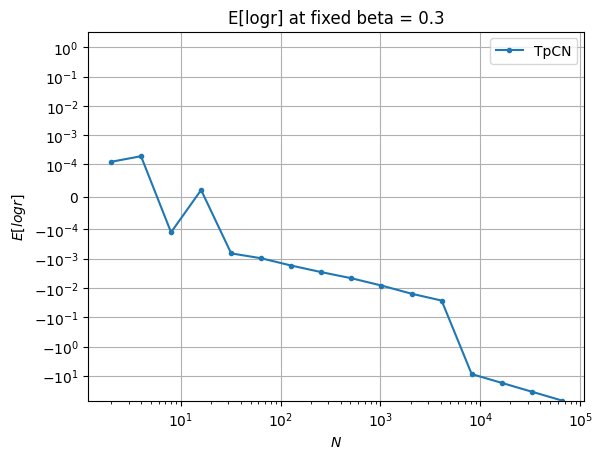

In [ ]:
plt.plot(test_x, rs,'.-',label='TpCN')
plt.legend()
plt.xscale('log')
plt.title('E[logr] at fixed beta = 0.3')
plt.yscale('symlog', linthresh=1e-4)
plt.xlabel('$N$')
plt.ylabel(r'$E[logr]$')
plt.grid()

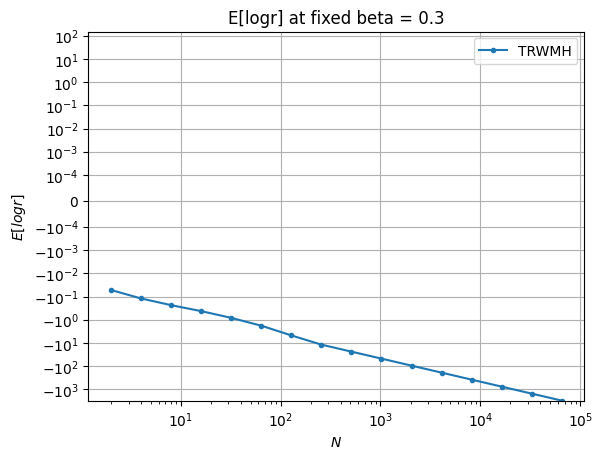

In [ ]:
plt.plot(test_x,rwrs,'.-',label='TRWMH')
plt.legend()
plt.xscale('log')
plt.title('E[logr] at fixed beta = 0.3')
plt.yscale('symlog', linthresh=1e-4)
plt.xlabel('$N$')
plt.ylabel(r'$E[logr]$')
plt.grid()

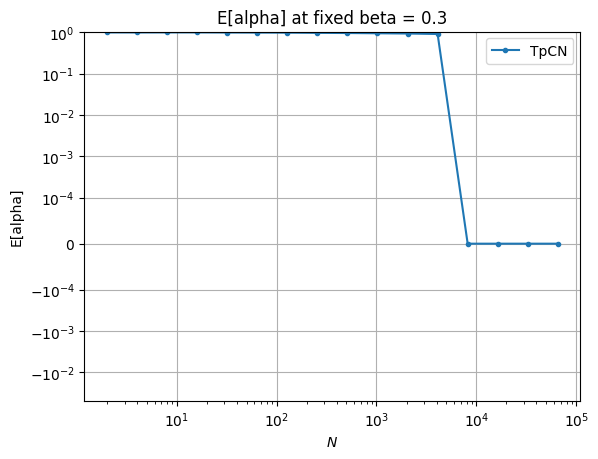

In [ ]:
plt.plot(test_x, stats,'.-',label='TpCN')
plt.legend()
plt.xscale('log')
plt.yscale('symlog', linthresh=1e-4)
plt.title('E[alpha] at fixed beta = 0.3')
plt.xlabel('$N$')
plt.ylabel('E[alpha]')
plt.grid()

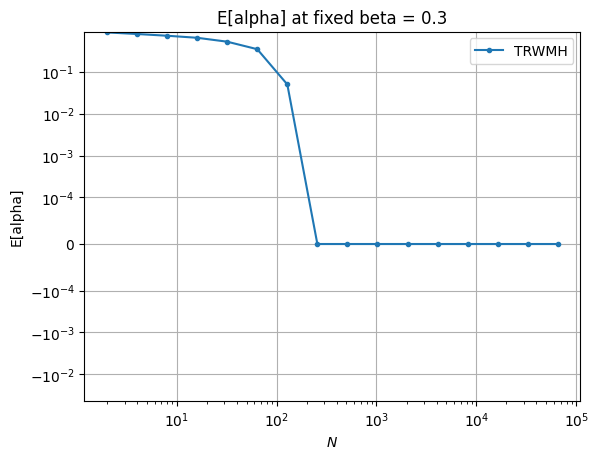

In [ ]:
plt.plot(test_x,rwstats,'.-',label='TRWMH')
plt.legend()
plt.xscale('log')
plt.yscale('symlog', linthresh=1e-4)
plt.title('E[alpha] at fixed beta = 0.3')
plt.xlabel('$N$')
plt.ylabel('E[alpha]')
plt.grid()

In [ ]:
scaled_rs = []
scaled_stats = []

for test_dim in test_x:
  beta = 0.5*test_dim**(-0.5)
  r, out = RWMH(key, beta, test_dim)
  scaled_stats = np.append(scaled_stats, out)
  scaled_rs = np.append(scaled_rs, r)

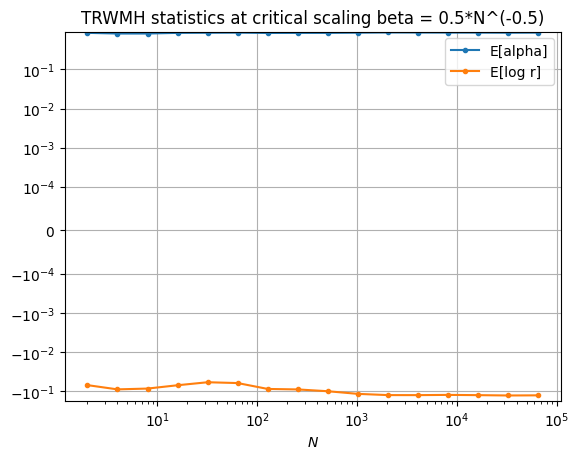

In [ ]:
plt.plot(test_x,scaled_stats,'.-',label='E[alpha]')
plt.plot(test_x, scaled_rs,'.-',label='E[log r]')
plt.legend()
plt.xscale('log')
plt.title('TRWMH statistics at critical scaling beta = 0.5*N^(-0.5)')
plt.yscale('symlog', linthresh=1e-4)
plt.xlabel('$N$')
plt.grid()